In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Import Data

In [14]:
df = pd.read_excel('chapter04_data.xlsx', sheet_name='embedding')

In [92]:
df

,Unnamed: 0,k,No-embed + Kmeans,PCA + Kmeans,DAE+ + Kmeans,No-embed + Spectral,PCA + Spectral,DAE+ + Spectral,"DAE+ Agglom [DTW, centroid]",Improvement over PCA with DAE-kmeans,Improvement over PCA with DAE-Agglom+,Unnamed: 11,Unnamed: 12,Unnamed: 13,DAE+ Agglom-knn
0,BR,3,0.5661,0.7625,0.7685,0.5203,0.4722,0.7233,0.7588,1.007869,0.995148,-0.012721,NaN,NaN,0.8016
1,BR,4,0.5074,0.6950,0.7321,0.4871,0.5705,0.5982,0.7171,1.053381,1.031799,-0.021583,NaN,NaN,0.7100
2,BR,5,0.4400,0.6041,0.7031,0.4156,0.5815,0.6296,0.6991,1.163880,1.157259,-0.006621,NaN,NaN,0.7148
3,BR,6,0.3886,0.5890,0.7224,0.3824,0.4984,0.5830,0.6413,1.226486,1.088795,-0.137691,NaN,NaN,0.6836
4,BR,7,0.3610,0.5566,0.6537,0.3361,0.4921,0.5748,0.6711,1.174452,1.205713,0.031261,NaN,NaN,0.6258
5,BR,8,0.3285,0.5487,0.6007,0.2643,0.4933,0.4937,0.6365,1.094769,1.160015,0.065245,NaN,NaN,0.5886
6,BR,9,0.2790,0.5370,0.5601,0.2383,0.4876,0.5040,0.6098,1.043017,1.135568,0.092551,NaN,NaN,0.5697
7,BR,10,0.2676,0.5243,0.5487,0.2639,0.4700,0.4793,0.5669,1.046538,1.081251,0.034713,NaN,NaN,0.5343
8,ECV,3,0.6214,0.6228,0.9424,0.3162,-0.0744,0.3174,0.9096,1.513166,1.460501,-0.052665,NaN,NaN,0.9198
9,ECV,4,0.6180,0.6210,0.8998,0.1797,-0.0103,0.3752,0.8927,1.448953,1.437520,-0.011433,NaN,NaN,0.8902


In [62]:
df.columns

Index(['Unnamed: 0', 'k', 'No-embed + Kmeans', 'PCA + Kmeans', 'DAE+ + Kmeans',
       'No-embed + Spectral', 'PCA + Spectral', 'DAE+ + Spectral',
       'DAE+ Agglom [DTW, centroid]', 'Improvement over PCA with DAE-kmeans',
       'Improvement over PCA with DAE-Agglom+', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'DAE+ Agglom-knn'],
      dtype='object')

# Plots

## Vary embedding method; k=3; clustering = k-means

In [113]:
subset = df[df['k']==3]

In [115]:
subset_long = pd.melt(subset, id_vars=['Unnamed: 0', 'k'], value_vars=['No-embed + Kmeans', 'PCA + Kmeans', 'DAE+ + Kmeans'])

In [117]:
subset_long.head()

,Unnamed: 0,k,variable,value
0,BR,3,No-embed + Kmeans,0.5661
1,ECV,3,No-embed + Kmeans,0.6214
2,FF,3,No-embed + Kmeans,0.8319
3,BR,3,PCA + Kmeans,0.7625
4,ECV,3,PCA + Kmeans,0.6228


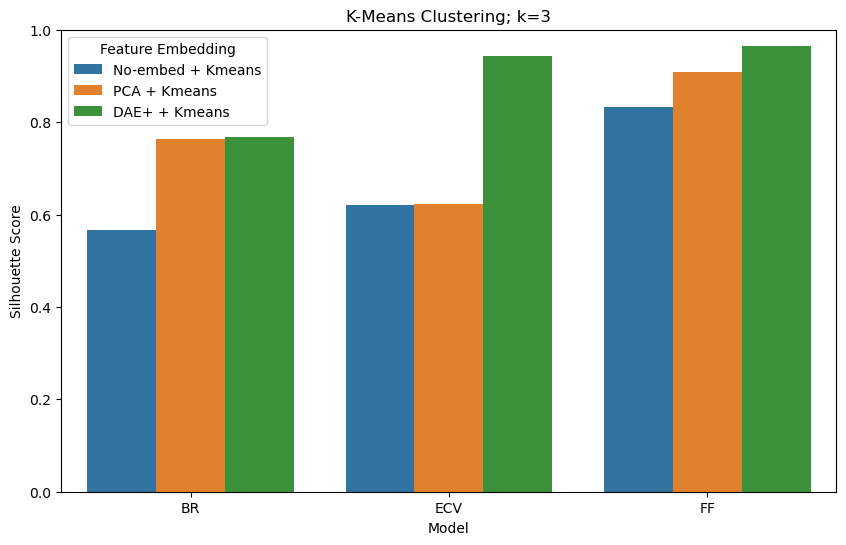

In [119]:
plt.figure(figsize=(10, 6))
sns.barplot(data=subset_long, x="Unnamed: 0", y="value", hue="variable")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("K-Means Clustering; k=3")
plt.legend(title="Feature Embedding")
plt.ylim(0, 1)
plt.savefig("kmeans_embedding_k3_comp.png", format="png")
plt.show()

## Vary k; vary embedding method; clustering = k-means; data = br

In [72]:
subset = df[df['Unnamed: 0']=='BR']

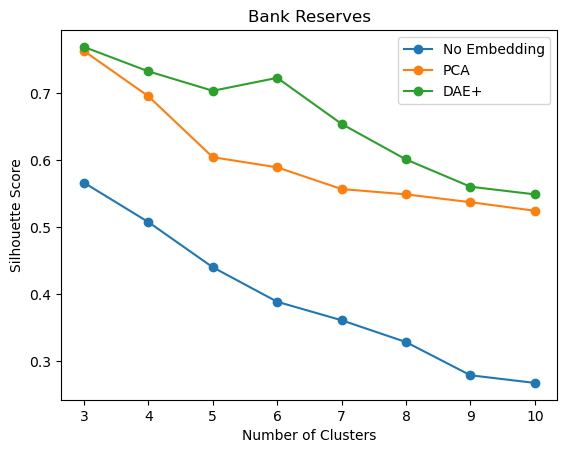

In [74]:
plt.plot(subset['k'], subset['No-embed + Kmeans'], label = "No Embedding", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['PCA + Kmeans'], label = "PCA", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ + Kmeans'], label = "DAE+", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Bank Reserves")
plt.legend() 

plt.savefig('br_size_of_k_silhouette_new.png')

## Vary k; vary embedding method; clustering = k-means; data = ecv

In [77]:
subset = df[df['Unnamed: 0']=='ECV']

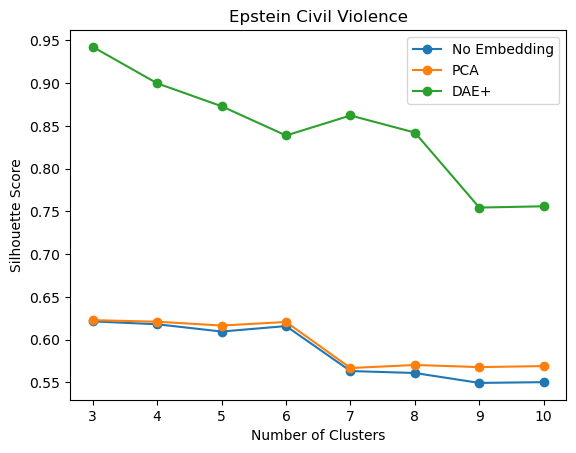

In [79]:
plt.plot(subset['k'], subset['No-embed + Kmeans'], label = "No Embedding", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['PCA + Kmeans'], label = "PCA", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ + Kmeans'], label = "DAE+", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Epstein Civil Violence")
plt.legend() 

plt.savefig('ecv_size_of_k_silhouette_new.png')

## Vary k; vary embedding method; clustering = k-means; data = ff

In [150]:
subset = df[df['Unnamed: 0']=='FF']

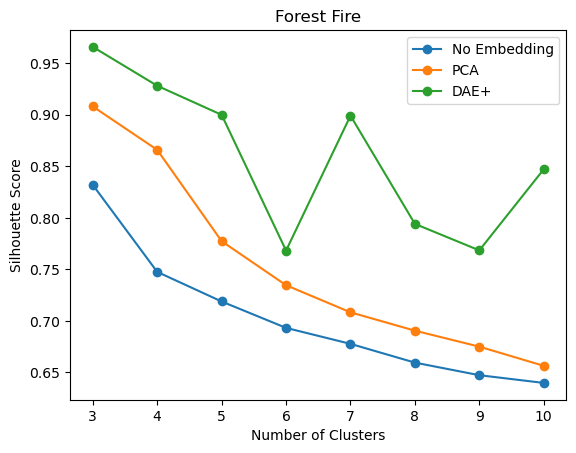

In [152]:
plt.plot(subset['k'], subset['No-embed + Kmeans'], label = "No Embedding", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['PCA + Kmeans'], label = "PCA", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ + Kmeans'], label = "DAE+", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Forest Fire")
plt.legend() 

plt.savefig('ff_size_of_k_silhouette_new.png')

## Vary embedding method; clustering = k-means; data = all; k - best for abm

In [94]:
subset = df.iloc[[4, 13, 17]]

In [96]:
subset

,Unnamed: 0,k,No-embed + Kmeans,PCA + Kmeans,DAE+ + Kmeans,No-embed + Spectral,PCA + Spectral,DAE+ + Spectral,"DAE+ Agglom [DTW, centroid]",Improvement over PCA with DAE-kmeans,Improvement over PCA with DAE-Agglom+,Unnamed: 11,Unnamed: 12,Unnamed: 13,DAE+ Agglom-knn
4,BR,7,0.3610,0.5566,0.6537,0.3361,0.4921,0.5748,0.6711,1.174452,1.205713,0.031261,NaN,NaN,0.6258
13,ECV,8,0.5610,0.5704,0.8422,0.2862,0.2749,0.4106,0.8593,1.476508,1.506487,0.029979,NaN,NaN,0.7211
17,FF,4,0.7475,0.8659,0.9281,0.1144,0.1444,0.5218,0.9266,1.071833,1.070100,-0.001732,NaN,NaN,0.9027


In [100]:
subset_long = pd.melt(subset, id_vars=['Unnamed: 0', 'k'], value_vars=['No-embed + Kmeans', 'PCA + Kmeans', 'DAE+ + Kmeans'])

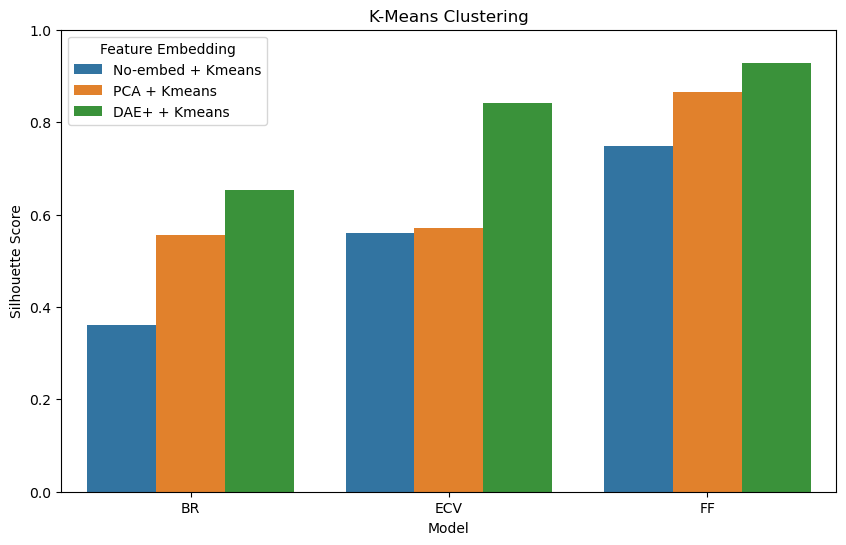

In [102]:
plt.figure(figsize=(10, 6))
sns.barplot(data=subset_long, x="Unnamed: 0", y="value", hue="variable")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("K-Means Clustering")
plt.legend(title="Feature Embedding")
plt.ylim(0, 1)
plt.savefig("kmeans_embedding_bestk_comp.png", format="png")
plt.show()

## Vary clustering method; embedding = dae+; data = all; k - 3

In [121]:
subset = df[df['k']==3]

In [123]:
subset_long = pd.melt(subset, id_vars=['Unnamed: 0', 'k'], value_vars=['DAE+ + Kmeans', 'DAE+ + Spectral', 'DAE+ Agglom-knn'])

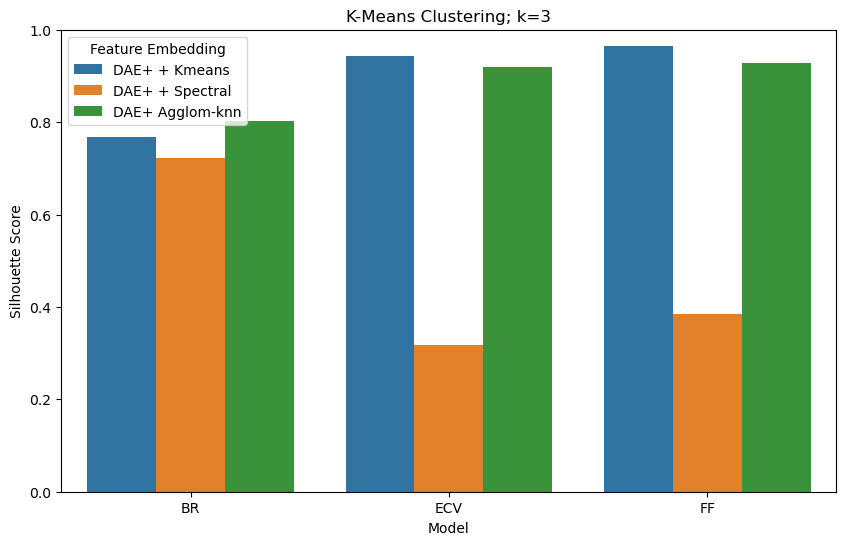

In [125]:
plt.figure(figsize=(10, 6))
sns.barplot(data=subset_long, x="Unnamed: 0", y="value", hue="variable")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("K-Means Clustering; k=3")
plt.legend(title="Feature Embedding")
plt.ylim(0, 1)
plt.savefig("allcluster_embedding_k3_comp.png", format="png")
plt.show()

## Compare agglom method; embedding = dae+; data = br

In [159]:
subset = df[df['Unnamed: 0']=='BR']

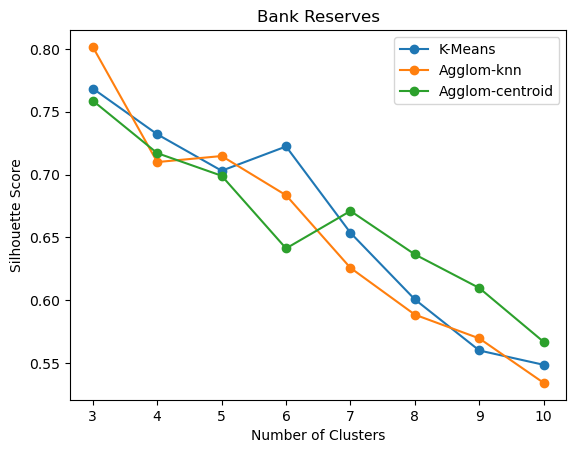

In [161]:
plt.plot(subset['k'], subset['DAE+ + Kmeans'], label = "K-Means", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ Agglom-knn'], label = "Agglom-knn", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ Agglom [DTW, centroid]'], label = "Agglom-centroid", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Bank Reserves")
plt.legend() 

plt.savefig('br_size_of_k_agglom_new.png')

## Compare agglom method; embedding = dae+; data = ecv

In [196]:
subset = df[df['Unnamed: 0']=='ECV']

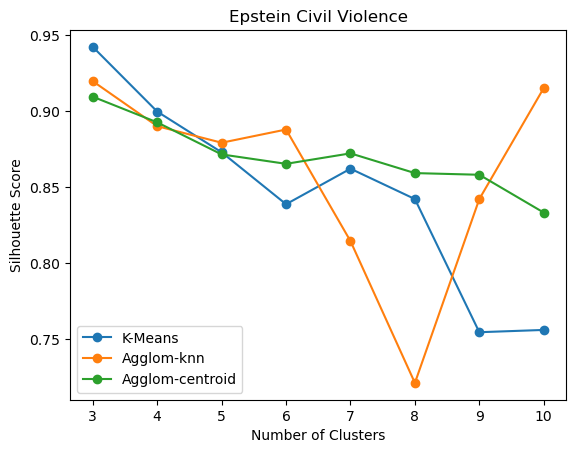

In [198]:
plt.plot(subset['k'], subset['DAE+ + Kmeans'], label = "K-Means", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ Agglom-knn'], label = "Agglom-knn", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ Agglom [DTW, centroid]'], label = "Agglom-centroid", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Epstein Civil Violence")
plt.legend() 

plt.savefig('ecv_size_of_k_agglom_new.png')

## Compare agglom method; embedding = dae+; data = ff

In [194]:
subset = df[df['Unnamed: 0']=='FF']

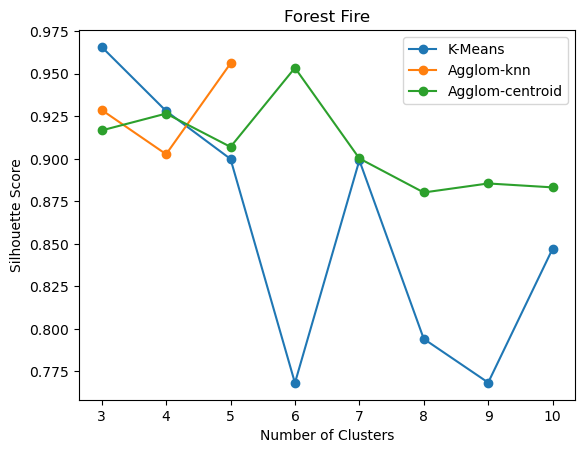

In [174]:
plt.plot(subset['k'], subset['DAE+ + Kmeans'], label = "K-Means", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ Agglom-knn'], label = "Agglom-knn", linestyle = 'solid', marker = 'o')
plt.plot(subset['k'], subset['DAE+ Agglom [DTW, centroid]'], label = "Agglom-centroid", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Forest Fire")
plt.legend() 

plt.savefig('ff_size_of_k_agglom_new.png')

## Compare agglom method; embedding = dae+; data = all

In [183]:
subset = df.iloc[[4, 13, 17]]

In [185]:
subset_long = pd.melt(subset, id_vars=['Unnamed: 0', 'k'], value_vars=['DAE+ + Kmeans', 'DAE+ Agglom-knn', 'DAE+ Agglom [DTW, centroid]'])

In [200]:
subset_long

,Unnamed: 0,k,variable,value
0,BR,7,DAE+ + Kmeans,0.6537
1,ECV,8,DAE+ + Kmeans,0.8422
2,FF,4,DAE+ + Kmeans,0.9281
3,BR,7,DAE+ Agglom-knn,0.6258
4,ECV,8,DAE+ Agglom-knn,0.7211
5,FF,4,DAE+ Agglom-knn,0.9027
6,BR,7,"DAE+ Agglom [DTW, centroid]",0.6711
7,ECV,8,"DAE+ Agglom [DTW, centroid]",0.8593
8,FF,4,"DAE+ Agglom [DTW, centroid]",0.9266


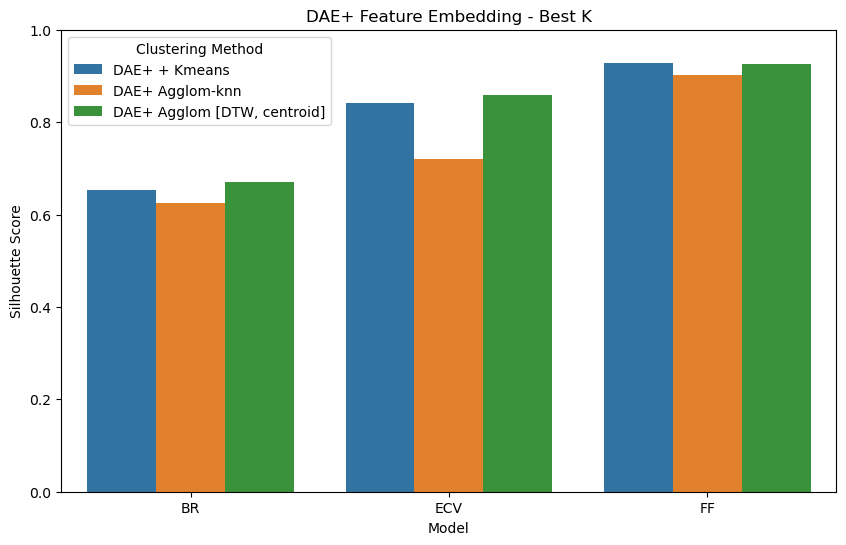

In [202]:
plt.figure(figsize=(10, 6))
sns.barplot(data=subset_long, x="Unnamed: 0", y="value", hue="variable")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("DAE+ Feature Embedding - Best K")
plt.legend(title="Clustering Method")
plt.ylim(0, 1)
plt.savefig("daep_clustering_bestk_comp.png", format="png")
plt.show()